* EX1.6 (1 point) Create a Python script to produce the following plot using Matplotlib. Requirements:
    - Plot measured data with error bars and compare against the reference function
    - Add a shaded uncertainty band with `fill_between`
    - Save as `ex1_6.png`
    - HINT: the data can be generated using the following lines of code:
    - Rules: you have to send the code with the solution of the exercise (.html) + the graphic the code produces.
    - Note that the solution showcased here include our python pet snake.
    - Your graphics must be free of snakes (i.e. please do not send us the figure included in this lecture!).
    
```python
    # Data set
    N_sample_points = 20          # Number of points plotted
    x_min = 0             # Lower value of the range of the data
    x_max = np.pi               # Higher value of the range of the data
    def ref_function(x):
        return np.cos(x)+np.cos(x**2)

    x = np.linspace(x_min, x_max, N_sample_points)

    y = np.array([ 2.14234667,  1.88911004,  1.79480494,  1.73942994,  1.43291172,  1.57731413,
          1.27047891,  0.98877325,  0.15915277, -0.52058165, -1.19948842, -1.39382868,
         -0.91996011, -0.63770412, -0.20389612,  0.0598823,  -0.38393458, -1.02237755,
         -2.13237608, -1.83003727])

    error_y= y-ref_function(x)
```

Solution:

<img src="figs/ex3_3.png" alt="image" width="400" height="auto">
  

In [6]:
import numpy as np
import matplotlib.pyplot as plt
# =============================================================================
# Data set
# =============================================================================
N_sample_points = 20  # Number of plotted points
x_min = 0             # Lower value of the data range
x_max = np.pi         # Upper value of the data range

figsize = (5,5)
dpi = 75
x_label = 'x / rad'
y_label = 'f(x)'

In [5]:

"""
Generate a comparison plot between experimental data and a reference function,
including uncertainty bands and residuals.

Inputs:
    N_sample_points: Number of sample points.
    x_min: Lower limit of the x-axis range.
    x_max: Upper limit of the x-axis range.
    figsize: Figure size.
    dpi: Figure resolution.
    x_label: Label for the x-axis.
    y_label: Label for the y-axis.

Output:
    A figure showing the reference function, experimental data with
    uncertainty, and the corresponding residuals. The figure is saved
    as "ex1_6.png" and displayed on the screen.
"""


def ref_function(x):
    return np.cos(x) + np.cos(x**2)

x = np.linspace(x_min, x_max, N_sample_points)

y = np.array([ 2.14234667,  1.88911004,  1.79480494,  1.73942994,  1.43291172,  1.57731413,
          1.27047891,  0.98877325,  0.15915277, -0.52058165, -1.19948842, -1.39382868,
         -0.91996011, -0.63770412, -0.20389612,  0.0598823,  -0.38393458, -1.02237755,
         -2.13237608, -1.83003727])

error_y = y - ref_function(x)

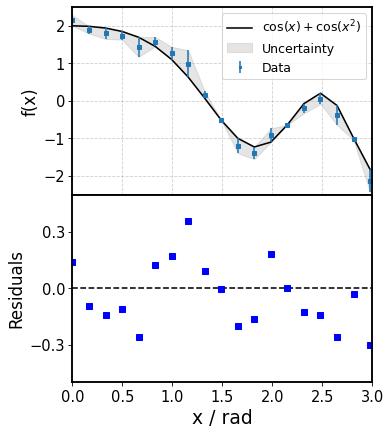

In [8]:
# =============================================================================
# Create the figure and axes objects
# =============================================================================
fig = plt.figure(figsize=figsize, dpi=dpi)

# (1) Main plot
ax1 = fig.add_axes([0, 0.5, 0.8, 0.5],
                   xticklabels=[]
                  )

# (2) Residuals plot
ax2 = fig.add_axes([0, 0, 0.8, 0.5])

# =============================================================================
# Upper plot
# =============================================================================

ax1.plot(x,
         ref_function(x),
         '-',
         color='black',
         linewidth=1.5,
         label=r'$\cos(x) + \cos(x^2)$')

ax1.fill_between(x,
                 y - np.abs(error_y),
                 y + np.abs(error_y),
                 color='gray',
                 alpha=0.2,
                 label='Uncertainty')

ax1.errorbar(x,
             y,
             yerr=np.abs(error_y),       # Add vertical error bars
             fmt='s',                    # Use square markers
             markersize=3,
             color='tab:blue',
             label='Data')

# =============================================================================
# Lower plot: residuals
# =============================================================================
ax2.axhline(0,
            color='black',
            linestyle='--')

ax2.plot(x,
         error_y,
         's',
         color='blue')

# =============================================================================
# Axes limits
# =============================================================================
ax1.set_xlim(0,3)
ax2.set_xlim(0,3)

ax1.set_ylim(-2.5,2.5)
ax2.set_ylim(-0.5,0.5)

# =============================================================================
# Tick positions
# =============================================================================
ax2.set_xticks(np.arange(0,3.1,0.5))
ax1.set_yticks(np.arange(-2,3,1))
ax2.set_yticks([-0.3,0,0.3])

# =============================================================================
# Axis labels
# =============================================================================
ax1.set_ylabel(y_label, fontsize=16)
ax2.set_ylabel('Residuals', fontsize=16)
ax2.set_xlabel(x_label, fontsize=18)

# =============================================================================
# Grid
# =============================================================================
ax1.grid(True, linestyle='--', alpha=0.6)

# =============================================================================
# Apply styles (tick labels and border width) to both axes
# =============================================================================
for ax in [ax1, ax2]:
    ax.tick_params(labelsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

ax1.legend(loc="upper right",
           fontsize=12,
           markerscale=0.9)

# =============================================================================
# Save the figure and display
# =============================================================================
fig.savefig('ex1_6.png', bbox_inches='tight')
plt.show()